# A1. Fixed-composition C–H–O mixture: comparison of three EOS

This demonstration compares the ideal, second-virial, and Peng–Robinson (PR) equations of state for the frozen gas composition

$$
(x_{\mathrm{CO}},x_{\mathrm{H_2O}},x_{\mathrm{CO_2}},x_{\mathrm{H_2}})
=(0.4,0.4,0.1,0.1).
$$

The temperature is fixed at $T=1000$ K and pressure spans $10^{-3}$–$10^3$ bar. The composition is deliberately held fixed: no water-gas-shift reaction or phase-equilibrium calculation is performed. All ExoEOS inputs use SI units, so pressure is converted from bar to Pa before evaluation.

## Model definition

The PR model uses critical properties bundled with ExoEOS. Their source records are the CoolProp fluid-information pages for [CO](https://coolprop.org/fluid_properties/fluids/CarbonMonoxide.html), [H2O](https://coolprop.org/fluid_properties/fluids/Water.html), [CO2](https://coolprop.org/fluid_properties/fluids/CarbonDioxide.html), and [H2](https://coolprop.org/fluid_properties/fluids/Hydrogen.html). Binary interaction parameters are set to $k_{ij}=0$ as a pedagogical simplifying assumption.

For a controlled comparison, the second-virial matrix is the exact low-density expansion of the same PR model at 1000 K,

$$
B_{ij}(T)=\frac{b_i+b_j}{2}-\frac{a_{ij}(T)}{RT},
\qquad
a_{ij}=(1-k_{ij})\sqrt{a_i a_j}.
$$

Thus the second-virial result is a PR-consistent truncation, not an independent experimental virial correlation. Matching the first density correction isolates the effect of terms beyond second virial.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/exoeos_matplotlib")

from jax import config

config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from exoeos import (
    IdealEOS,
    PengRobinsonEOS,
    SecondVirialEOS,
    get_critical_properties,
    state_tp,
)
from exoeos.constants import MOLAR_GAS_CONSTANT

species = ("CO", "H2O", "CO2", "H2")
composition = jnp.asarray([0.4, 0.4, 0.1, 0.1])
temperature = 1000.0  # K
pressure_bar = jnp.logspace(-3.0, 3.0, 301)
pressure = pressure_bar * 1.0e5  # Pa

records = tuple(get_critical_properties(name) for name in species)
critical_temperatures = jnp.asarray(
    [record.critical_temperature for record in records]
)
critical_pressures = jnp.asarray(
    [record.critical_pressure for record in records]
)
acentric_factors = jnp.asarray([record.acentric_factor for record in records])

pr_eos = PengRobinsonEOS(
    critical_temperatures,
    critical_pressures,
    acentric_factors,
)
virial_coefficients = pr_eos.second_virial_coefficients(temperature)
eos_models = {
    "Ideal": IdealEOS(),
    "Second virial": SecondVirialEOS(virial_coefficients),
    "Peng-Robinson": pr_eos,
}

print(f"{'species':>7} {'x':>7} {'Tc [K]':>12} {'Pc [bar]':>12} {'omega':>12}")
for name, fraction, record in zip(species, composition, records):
    print(
        f"{name:>7} {float(fraction):7.3f} "
        f"{record.critical_temperature:12.6f} "
        f"{record.critical_pressure / 1.0e5:12.6f} "
        f"{record.acentric_factor:12.6f}"
    )

mixture_virial = composition @ virial_coefficients @ composition
print(f"\nB_mix(1000 K) = {float(mixture_virial) * 1.0e6:.6f} cm^3 mol^-1")

species       x       Tc [K]     Pc [bar]        omega
     CO   0.400   132.859895    34.981947     0.049700
    H2O   0.400   647.096000   220.640000     0.344292
    CO2   0.100   304.128200    73.772984     0.223940
     H2   0.100    33.144333    12.963576    -0.219000

B_mix(1000 K) = 9.448576 cm^3 mol^-1


## Evaluation and numerical checks

`state_tp` accepts one scalar state at a time, so `jax.vmap` evaluates the pressure grid. For every EOS we verify

$$
Z=\frac{P}{\rho RT},
\qquad
\frac{\rho}{\rho_{\mathrm{ideal}}}=\frac{1}{Z},
\qquad
\frac{g^r}{RT}=\sum_i x_i\ln\phi_i.
$$

The ideal state must also give $Z=1$, $\ln\phi_i=0$, and $g^r/RT=0$.

In [2]:
def evaluate_pressure_grid(eos):
    return jax.vmap(
        lambda value: state_tp(eos, temperature, value, composition)
    )(pressure)


states = {name: evaluate_pressure_grid(eos) for name, eos in eos_models.items()}
ideal_density = pressure / (MOLAR_GAS_CONSTANT * temperature)
density_ratios = {
    name: state.rho / ideal_density for name, state in states.items()
}

np.testing.assert_allclose(
    np.asarray(virial_coefficients),
    np.asarray(virial_coefficients.T),
    rtol=0.0,
    atol=1.0e-15,
)
for name, state in states.items():
    for value in jax.tree_util.tree_leaves(state):
        assert np.all(np.isfinite(np.asarray(value)))
    np.testing.assert_allclose(
        np.asarray(state.P), np.asarray(pressure), rtol=2.0e-12, atol=1.0e-8
    )
    np.testing.assert_allclose(
        np.asarray(density_ratios[name]),
        np.asarray(1.0 / state.Z),
        rtol=2.0e-12,
        atol=1.0e-14,
    )
    np.testing.assert_allclose(
        np.asarray(state.gres_RT),
        np.asarray(state.lnphi @ composition),
        rtol=2.0e-12,
        atol=1.0e-14,
    )

ideal_state = states["Ideal"]
np.testing.assert_allclose(np.asarray(ideal_state.Z), 1.0, rtol=0.0, atol=1.0e-14)
np.testing.assert_allclose(np.asarray(ideal_state.lnphi), 0.0, rtol=0.0, atol=1.0e-14)
np.testing.assert_allclose(
    np.asarray(ideal_state.gres_RT), 0.0, rtol=0.0, atol=1.0e-14
)

pr_state = states["Peng-Robinson"]
virial_state = states["Second virial"]
low_pressure_indices = np.asarray([0, 50, 100])  # 0.001, 0.01, 0.1 bar
low_pressure_delta_z = np.abs(
    np.asarray(pr_state.Z - virial_state.Z)[low_pressure_indices]
)
decade_growth = low_pressure_delta_z[1:] / low_pressure_delta_z[:-1]
assert np.all((decade_growth > 90.0) & (decade_growth < 110.0))

print("All thermodynamic identities and finite-value checks passed.")
for name in ("Second virial", "Peng-Robinson"):
    state = states[name]
    print(
        f"{name:>15} at 0.001 bar: "
        f"Z - 1 = {float(state.Z[0] - 1.0):.3e}, "
        f"max abs(ln(phi_i)) = {float(jnp.max(jnp.abs(state.lnphi[0]))):.3e}"
    )

print("\nValues at 1000 bar:")
for name, state in states.items():
    print(
        f"{name:>15}: rho = {float(state.rho[-1]):10.3f} mol m^-3, "
        f"Z = {float(state.Z[-1]):.6f}, "
        f"g^r/RT = {float(state.gres_RT[-1]):.6f}"
    )

All thermodynamic identities and finite-value checks passed.
  Second virial at 0.001 bar: Z - 1 = 1.136e-07, max abs(ln(phi_i)) = 3.641e-07
  Peng-Robinson at 0.001 bar: Z - 1 = 1.136e-07, max abs(ln(phi_i)) = 3.641e-07

Values at 1000 bar:
          Ideal: rho =  12027.236 mol m^-3, Z = 1.000000, g^r/RT = 0.000000
  Second virial: rho =  10903.856 mol m^-3, Z = 1.103026, g^r/RT = 0.107995
  Peng-Robinson: rho =  10091.534 mol m^-3, Z = 1.191814, g^r/RT = 0.159990


## EOS observables

The four panels show the compressibility factor, molar-density ratio, component fugacity coefficients, and reduced residual Gibbs energy. Density is a molar density in ExoEOS, but $\rho/\rho_{\mathrm{ideal}}=1/Z$ is also the mass-density ratio for a fixed composition.

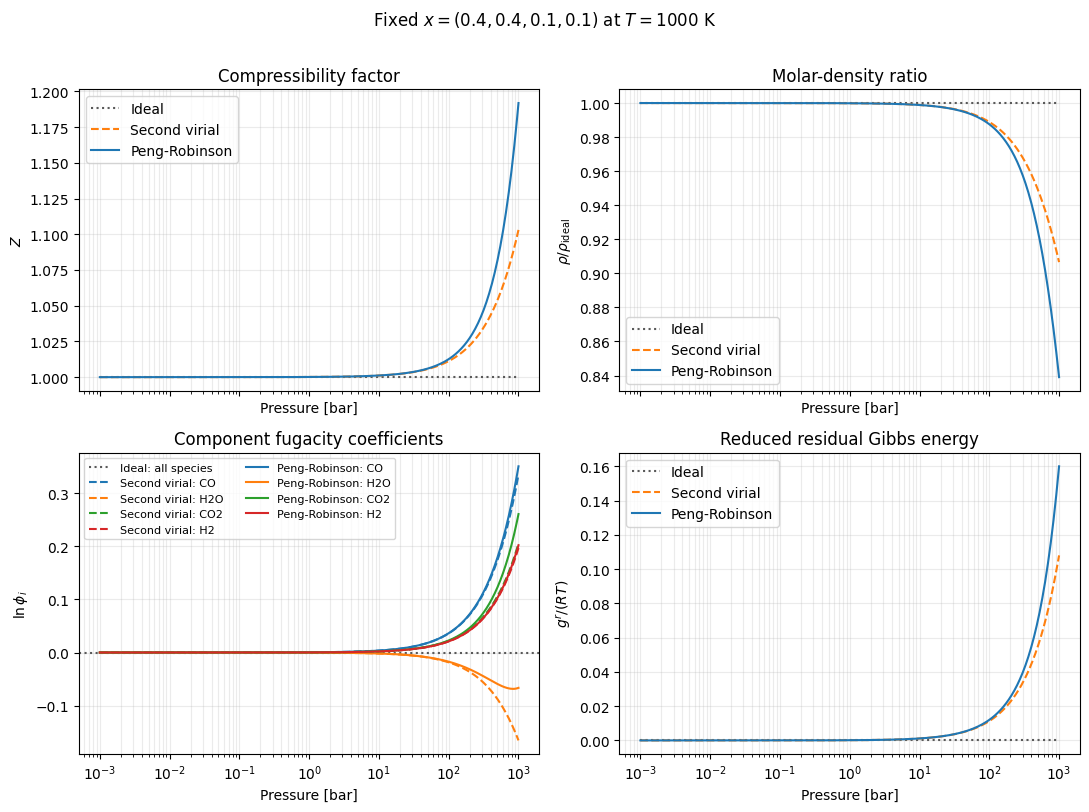

In [3]:
model_styles = {
    "Ideal": {"color": "0.35", "linestyle": ":"},
    "Second virial": {"color": "tab:orange", "linestyle": "--"},
    "Peng-Robinson": {"color": "tab:blue", "linestyle": "-"},
}
species_colors = dict(zip(species, plt.get_cmap("tab10").colors[:4]))

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.0), sharex=True)

for name, state in states.items():
    axes[0, 0].plot(pressure_bar, state.Z, label=name, **model_styles[name])
    axes[0, 1].plot(
        pressure_bar, density_ratios[name], label=name, **model_styles[name]
    )
    axes[1, 1].plot(
        pressure_bar, state.gres_RT, label=name, **model_styles[name]
    )

axes[1, 0].axhline(0.0, color="0.35", linestyle=":", label="Ideal: all species")
for model_name, linestyle in (("Second virial", "--"), ("Peng-Robinson", "-")):
    for index, species_name in enumerate(species):
        axes[1, 0].plot(
            pressure_bar,
            states[model_name].lnphi[:, index],
            color=species_colors[species_name],
            linestyle=linestyle,
            label=f"{model_name}: {species_name}",
        )

axes[0, 0].set_ylabel(r"$Z$")
axes[0, 0].set_title("Compressibility factor")
axes[0, 1].set_ylabel(r"$\rho/\rho_{\mathrm{ideal}}$")
axes[0, 1].set_title("Molar-density ratio")
axes[1, 0].set_ylabel(r"$\ln \phi_i$")
axes[1, 0].set_title("Component fugacity coefficients")
axes[1, 1].set_ylabel(r"$g^r/(RT)$")
axes[1, 1].set_title("Reduced residual Gibbs energy")

for axis in axes.flat:
    axis.set_xscale("log")
    axis.set_xlabel("Pressure [bar]")
    axis.grid(True, which="both", alpha=0.25)
axes[0, 0].legend()
axes[0, 1].legend()
axes[1, 0].legend(fontsize=8, ncols=2)
axes[1, 1].legend()
fig.suptitle(
    r"Fixed $x=(0.4,0.4,0.1,0.1)$ at $T=1000$ K", y=1.01
)
fig.tight_layout()
plt.show()

At low pressure, both non-ideal models converge to the ideal identities. Because their second virial coefficients are matched, their leading difference is quadratic in pressure; the numerical check above confirms an approximately 100-fold increase in $|\Delta Z|$ per pressure decade in the dilute limit. At high pressure the omitted higher-order density terms become visible.

## PR minus second-virial differences

The following panels use signed differences, PR minus second virial. Absolute relative errors are avoided because both residual quantities and their differences approach zero in the ideal-gas limit.

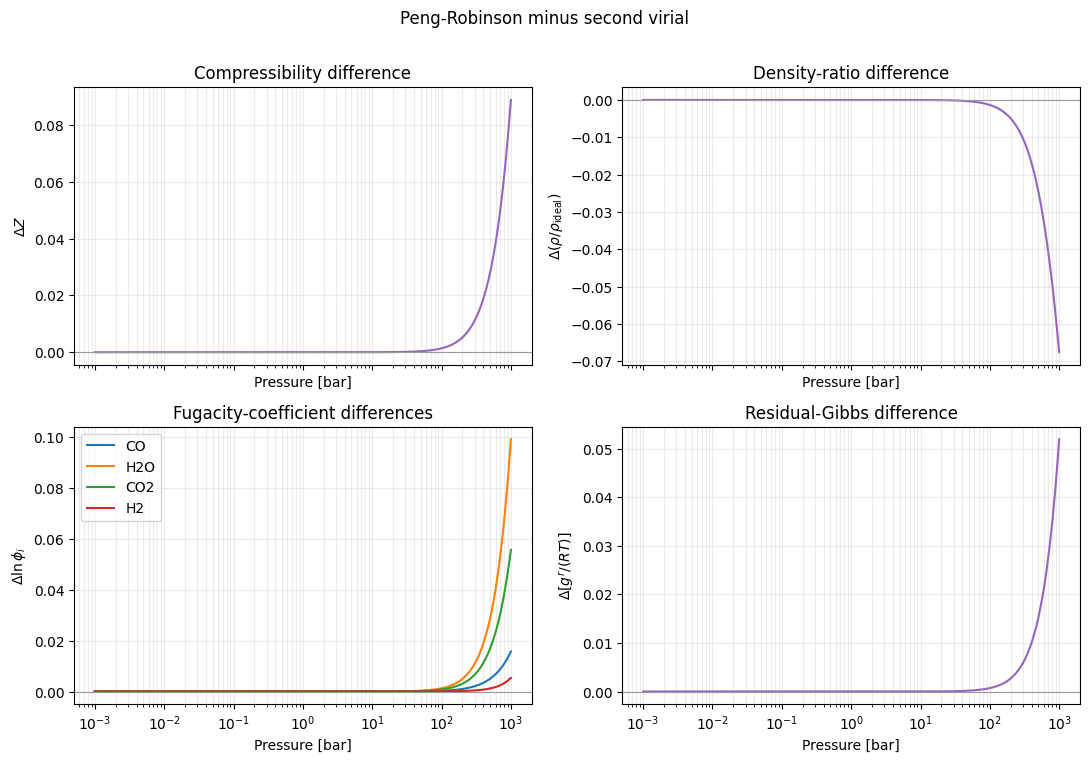

In [4]:
delta_z = pr_state.Z - virial_state.Z
delta_density_ratio = (
    density_ratios["Peng-Robinson"] - density_ratios["Second virial"]
)
delta_lnphi = pr_state.lnphi - virial_state.lnphi
delta_gres = pr_state.gres_RT - virial_state.gres_RT

fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.5), sharex=True)
axes[0, 0].plot(pressure_bar, delta_z, color="tab:purple")
axes[0, 1].plot(pressure_bar, delta_density_ratio, color="tab:purple")
for index, species_name in enumerate(species):
    axes[1, 0].plot(
        pressure_bar,
        delta_lnphi[:, index],
        color=species_colors[species_name],
        label=species_name,
    )
axes[1, 1].plot(pressure_bar, delta_gres, color="tab:purple")

axes[0, 0].set_ylabel(r"$\Delta Z$")
axes[0, 0].set_title("Compressibility difference")
axes[0, 1].set_ylabel(r"$\Delta(\rho/\rho_{\mathrm{ideal}})$")
axes[0, 1].set_title("Density-ratio difference")
axes[1, 0].set_ylabel(r"$\Delta\ln \phi_i$")
axes[1, 0].set_title("Fugacity-coefficient differences")
axes[1, 0].legend()
axes[1, 1].set_ylabel(r"$\Delta[g^r/(RT)]$")
axes[1, 1].set_title("Residual-Gibbs difference")

for axis in axes.flat:
    axis.axhline(0.0, color="0.6", linewidth=0.8)
    axis.set_xscale("log")
    axis.set_xlabel("Pressure [bar]")
    axis.grid(True, which="both", alpha=0.25)
fig.suptitle("Peng-Robinson minus second virial", y=1.01)
fig.tight_layout()
plt.show()

## Interpretation and limitations

- The ideal EOS gives $Z=1$, $\rho/\rho_{\mathrm{ideal}}=1$, $\ln\phi_i=0$, and $g^r/RT=0$ over the full grid.
- The second-virial and PR curves approach the ideal result at low pressure. Their matched low-density term makes the PR–virial difference an explicit measure of higher-order PR contributions.
- The second-virial curve above is extended to 1000 bar only to display truncation behavior. A second-virial EOS is a low-density approximation and its high-pressure values should not be interpreted as quantitatively reliable.
- Classical PR with $k_{ij}=0$, particularly for a water-containing mixture, is also a teaching model rather than an experimental benchmark. No claim of phase-equilibrium or reactive-equilibrium accuracy is made.
- If the temperature is changed, regenerate `virial_coefficients` with `pr_eos.second_virial_coefficients(new_temperature)` before repeating the comparison.